In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

import warnings
warnings.filterwarnings("ignore")

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,5)

In [3]:
df_raw = pd.read_csv("Titanic-Dataset.csv")
df = df_raw.copy()

FileNotFoundError: [Errno 2] No such file or directory: 'Titanic-Dataset.csv'

In [ ]:
# DATA CLEANING (PRODUCTION GRADE)
# Standardize Column Names

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

In [ ]:
# Fix Data Types

df['survived'] = df['survived'].astype(int)
df['sex'] = df['sex'].astype('category')
df['embarked'] = df['embarked'].astype('category')

In [ ]:
# Missing Value Treatment

# Age -> Median
df['age'] = df['age'].fillna(df['age'].median())

# Embarked -> Mode
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

# Cabin -> Drop (Too sparse)
df.drop(columns=['cabin'], inplace=True)

In [ ]:
# Duplicate Handling
df.drop_duplicates(inplace=True)

In [ ]:
# outlier Treatment (Capping)
Q1 = df['fare'].quantile(0.25)
Q3 = df['fare'].quantile(0.75)
IQR = Q3 - Q1

upper = Q3 + 1.5 * IQR

df['fare'] = np.where(df['fare'] > upper, upper, df['fare'])

In [ ]:
# FEATURE ENGINEERING

# Create New Features
df['family_size'] = df['sibsp'] + df['parch'] + 1
df['is_alone'] = np.where(df['family_size'] == 1, 1, 0)

In [ ]:
# Encoding (ML Ready)

df['sex'] = df['sex'].map({'male': 0, 'female': 1})
df['embarked'] = df['embarked'].map({'S': 0, 'C': 1, 'Q': 2})

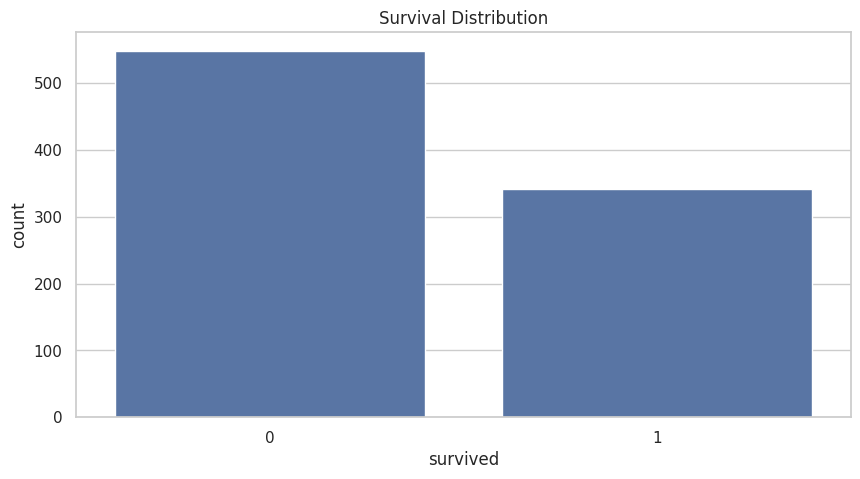

In [ ]:
# EXPLORATORY DATA ANALYSIS

# Target Distribution
sns.countplot(x='survived', data=df)
plt.title("Survival Distribution")
plt.show()

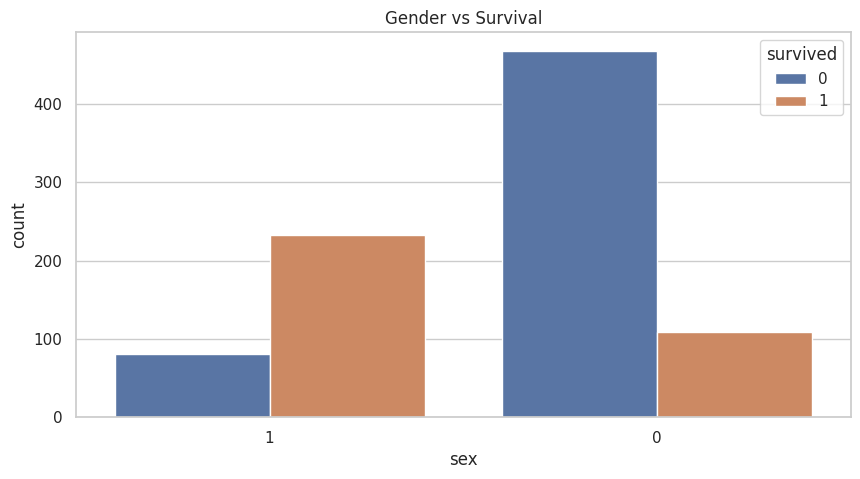

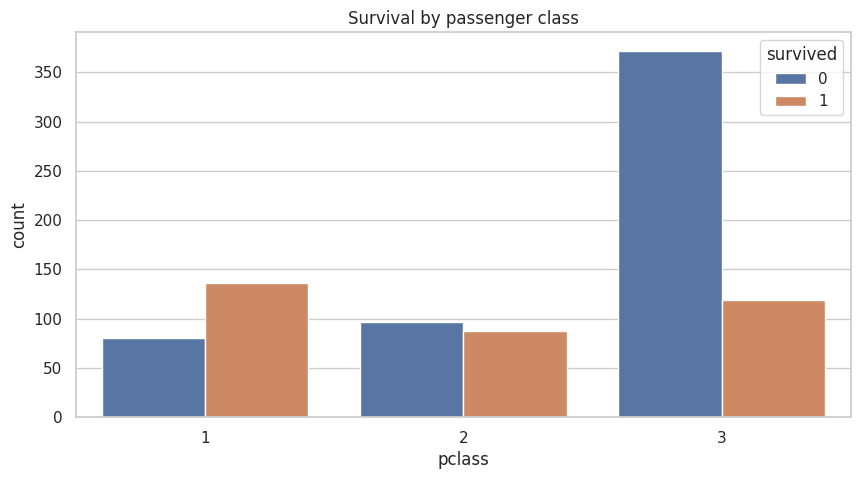

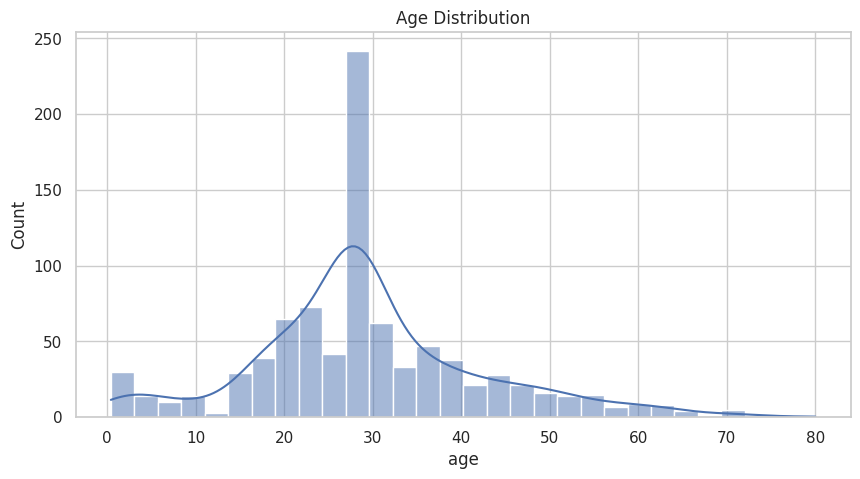

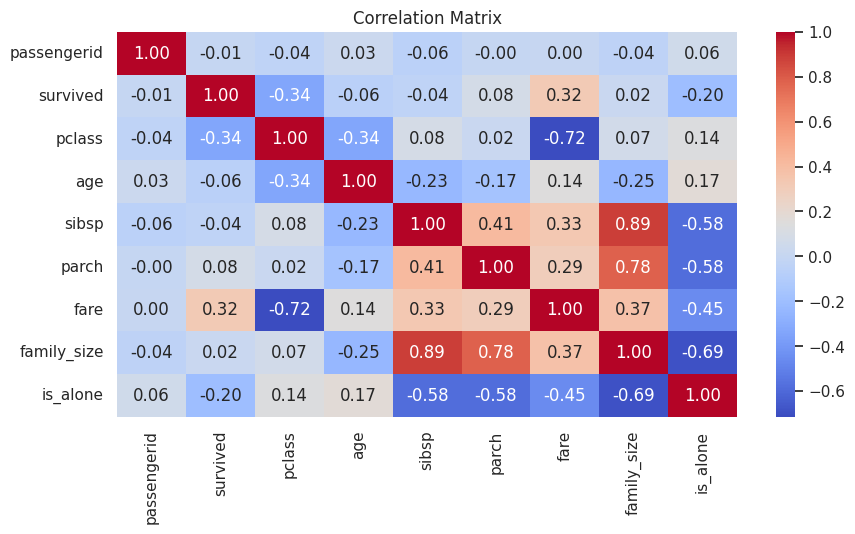

In [ ]:
# Gender vs Survival

sns.countplot(x='sex', hue='survived', data=df)
plt.title("Gender vs Survival")
plt.show()

# Class vs survival

sns.countplot(x='pclass', hue='survived', data=df)
plt.title("Survival by passenger class")
plt.show()

# Age Distribution
sns.histplot(df['age'], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

# Correlation Heatmap
corr = df.select_dtypes(include='number').corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [ ]:
# MACHIN LEARNING PIPELINE
# Feature Selection
features = [
    'pclass', 'sex', 'age', 'fare',
    'family_size', 'is_alone', 'embarked'
]

X = df[features]
y = df['survived']

# Train-Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model Training (Logistic Regression)
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

# Predictions
y_pres = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

In [1]:
# SAVE CLEAN DATA
df.to_csv("titanic_cleaned_final.csv",index=False)

NameError: name 'df' is not defined